# Dataframer: Richmond Latimore's Odyssey to Pandas DF

### [—————————————pipeline—————————————]
### »——raw—»—clean—»—normalize—»—DATAFRAME——»

Here are some transformation and frequencies for future exploratory analysis of Green's Odyssey.

Columns: author, year, title, book_num, text, num_lines, num_sentences, num_words, 


In [22]:
import numpy as np
import pandas as pd

import re
import nltk

import os

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/Users/debr/English-Homer') 
import bard_visualization as viz# This will apply the visualization settings

In [24]:
# TO UPDATE
translator = "Lattimore" 

# Check Paths
filepath = f"/Users/debr/odysseys_en/Normalized_txts/Odyssey_{translator}_Normalized_v2.txt"
output_path = f"/Users/debr/English-Homer/dataframers_by_author/{translator}_DFed/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_path_plots = f"{output_path}/plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

# READING FILE TO extracted_lines
with open(filepath, 'r') as file:
    extracted_lines = file.readlines()

text = "".join(extracted_lines)

In [ ]:
# Split the text into books
def string_into_books(text, book_breaker):
    """
    Split a string into books/sections based on a pattern.
    
    Args:
        text (str): Text to process
        book_breaker (str): Pattern that indicates the start of a new book/section
    
    Returns:
        list: List of strings, where each string contains the content for one book/section
    """
    books = re.split(rf'{book_breaker}\s', text)
    # Remove the first element (it's empty or contains text before the first "Book")
    if books[0].strip() == "": 
        books = books[1:] #
        print(len(books))
    else:
        print("Warning: There was text before the first 'Book'")
    return books

def list_into_books(lines_list, book_breaker):
    
    """
    Split a list of strings into books/sections based on a pattern,
    excluding the lines that contain the book_breaker pattern.
    
    Args:
        lines_list (list): List of strings to process
        book_breaker (str): Pattern that indicates the start of a new book/section
    
    Returns:
        list: List of lists, where each inner list contains lines for one book/section
    """
    books = []
    current_book = []
    
    for line in lines_list:
        if line.strip().startswith(book_breaker):
            # If we already have content in current_book, save it and start a new one
            if current_book:
                books.append(current_book)
                current_book = []
            
        else:
            # Add the line to the current book
            current_book.append(line)
    
    # if there's content, add the last book 
    if current_book:
        books.append(current_book)
    
    return books

In [26]:
book_breaker = "BOOK"

#books = string_into_books(text, book_breaker)
books = list_into_books(extracted_lines, book_breaker)

# Verify the results
print(f"Found {len(books)} books")
for i, book in enumerate(books):
    print(f"Book {i+1} starts with: {book[0]}")
    print(f"Book {i+1} has {len(book)} lines")

Found 24 books
Book 1 starts with: Tell me, Muse, of the man of many ways, who was driven

Book 1 has 455 lines
Book 2 starts with: Now when the young Dawn showed again with her rosy fingers, the dear

Book 2 has 442 lines
Book 3 starts with: Helios, leaving behind the lovely standing waters, rose up

Book 3 has 510 lines
Book 4 starts with: They came into the cavernous hollow of Lakedaimon

Book 4 has 871 lines
Book 5 starts with: Now Dawn rose from her bed, where she lay by haughty Tithonos,

Book 5 has 507 lines
Book 6 starts with: So long-suffering great Odysseus slept in that place

Book 6 has 334 lines
Book 7 starts with: So long-suffering great Odysseus prayed, in that place,

Book 7 has 353 lines
Book 8 starts with: Then when the young Dawn showed again with her rosy fingers,

Book 8 has 600 lines
Book 9 starts with: Then resourceful Odysseus spoke in turn and answered him: ‘O great

Book 9 has 568 lines
Book 10 starts with: ‘We came next to the Aiolian island, whereAiolos

Boo

In [27]:
# Populate Odyssey DF
def odyssey_dataframer(author, year, title, list_books):
    """
    Splits a list_books into rows and creates a DataFrame.
    Args:
    list_books (list): The full text of the Odyssey
    author (str): Author name
    year (str): Publication year
    title (str): Book title
    Returns:
    pd.DataFrame: DataFrame with columns for author, year, title, book_num, and text
    """
    data = []
    
    for i, book_text in enumerate(list_books, 1):  # Start counting from 1
        data.append({
            'author': author,
            'year': year,
            'title': title,
            'book_num': i,
            'text': book_text
        })
    
    # Create the DataFrame from the data
    df = pd.DataFrame(data)
    
    return df

In [ ]:
df = odyssey_dataframer(f"{translator}", "1965", "The Odyssey", books)
df

,author,year,title,book_num,text
0,Lattimore,1965,The Odyssey,1,"[Tell me, Muse, of the man of many ways, who w..."
1,Lattimore,1965,The Odyssey,2,[Now when the young Dawn showed again with her...
2,Lattimore,1965,The Odyssey,3,"[Helios, leaving behind the lovely standing wa..."
3,Lattimore,1965,The Odyssey,4,[They came into the cavernous hollow of Lakeda...
4,Lattimore,1965,The Odyssey,5,"[Now Dawn rose from her bed, where she lay by ..."
5,Lattimore,1965,The Odyssey,6,[So long-suffering great Odysseus slept in tha...
6,Lattimore,1965,The Odyssey,7,"[So long-suffering great Odysseus prayed, in t..."
7,Lattimore,1965,The Odyssey,8,[Then when the young Dawn showed again with he...
8,Lattimore,1965,The Odyssey,9,[Then resourceful Odysseus spoke in turn and a...
9,Lattimore,1965,The Odyssey,10,"[‘We came next to the Aiolian island, whereAio..."


In [29]:
# Functions to count lines, sentences, and words
def count_lines(text):
    """Function to count lines in a text by the number of newline characters.

    Args:
        text (list or str): The text as a list of lines or a string.

    Returns:
        int: The number of lines in the text.
    """
    if isinstance(text, list):
        return len(text)  # Each element in the list is a line
    if isinstance(text, float) and pd.isna(text):
        return 0
    if not isinstance(text, str):
        return 0
    return text.count('\n') + 1

def count_sentences(text):
    """Function to count sentences in a text.

    Args:
        text (list or str): The text as a list of lines or a string.

    Returns:
        int: The number of sentences in the text.
    """
    if isinstance(text, list):
        text = " ".join(text)  # Convert list of lines into a single string
    if isinstance(text, float) and pd.isna(text):
        return 0
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'[.!?]+', text))  # Count sentence endings

def count_words(text):
    """Count the number of words in a text.

    Args:
        text (list or str): The text as a list of lines or a string.

    Returns:
        int: The number of words in the text.
    """
    if isinstance(text, list):
        text = " ".join(text)  # Convert list of lines into a single string
    if isinstance(text, float) and pd.isna(text):
        return 0
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'\b\w+\b', text))

In [30]:
df['num_lines'] = df['text'].apply(count_lines)
df['num_sentences'] = df['text'].apply(count_sentences)
df['num_words'] = df['text'].apply(count_words)

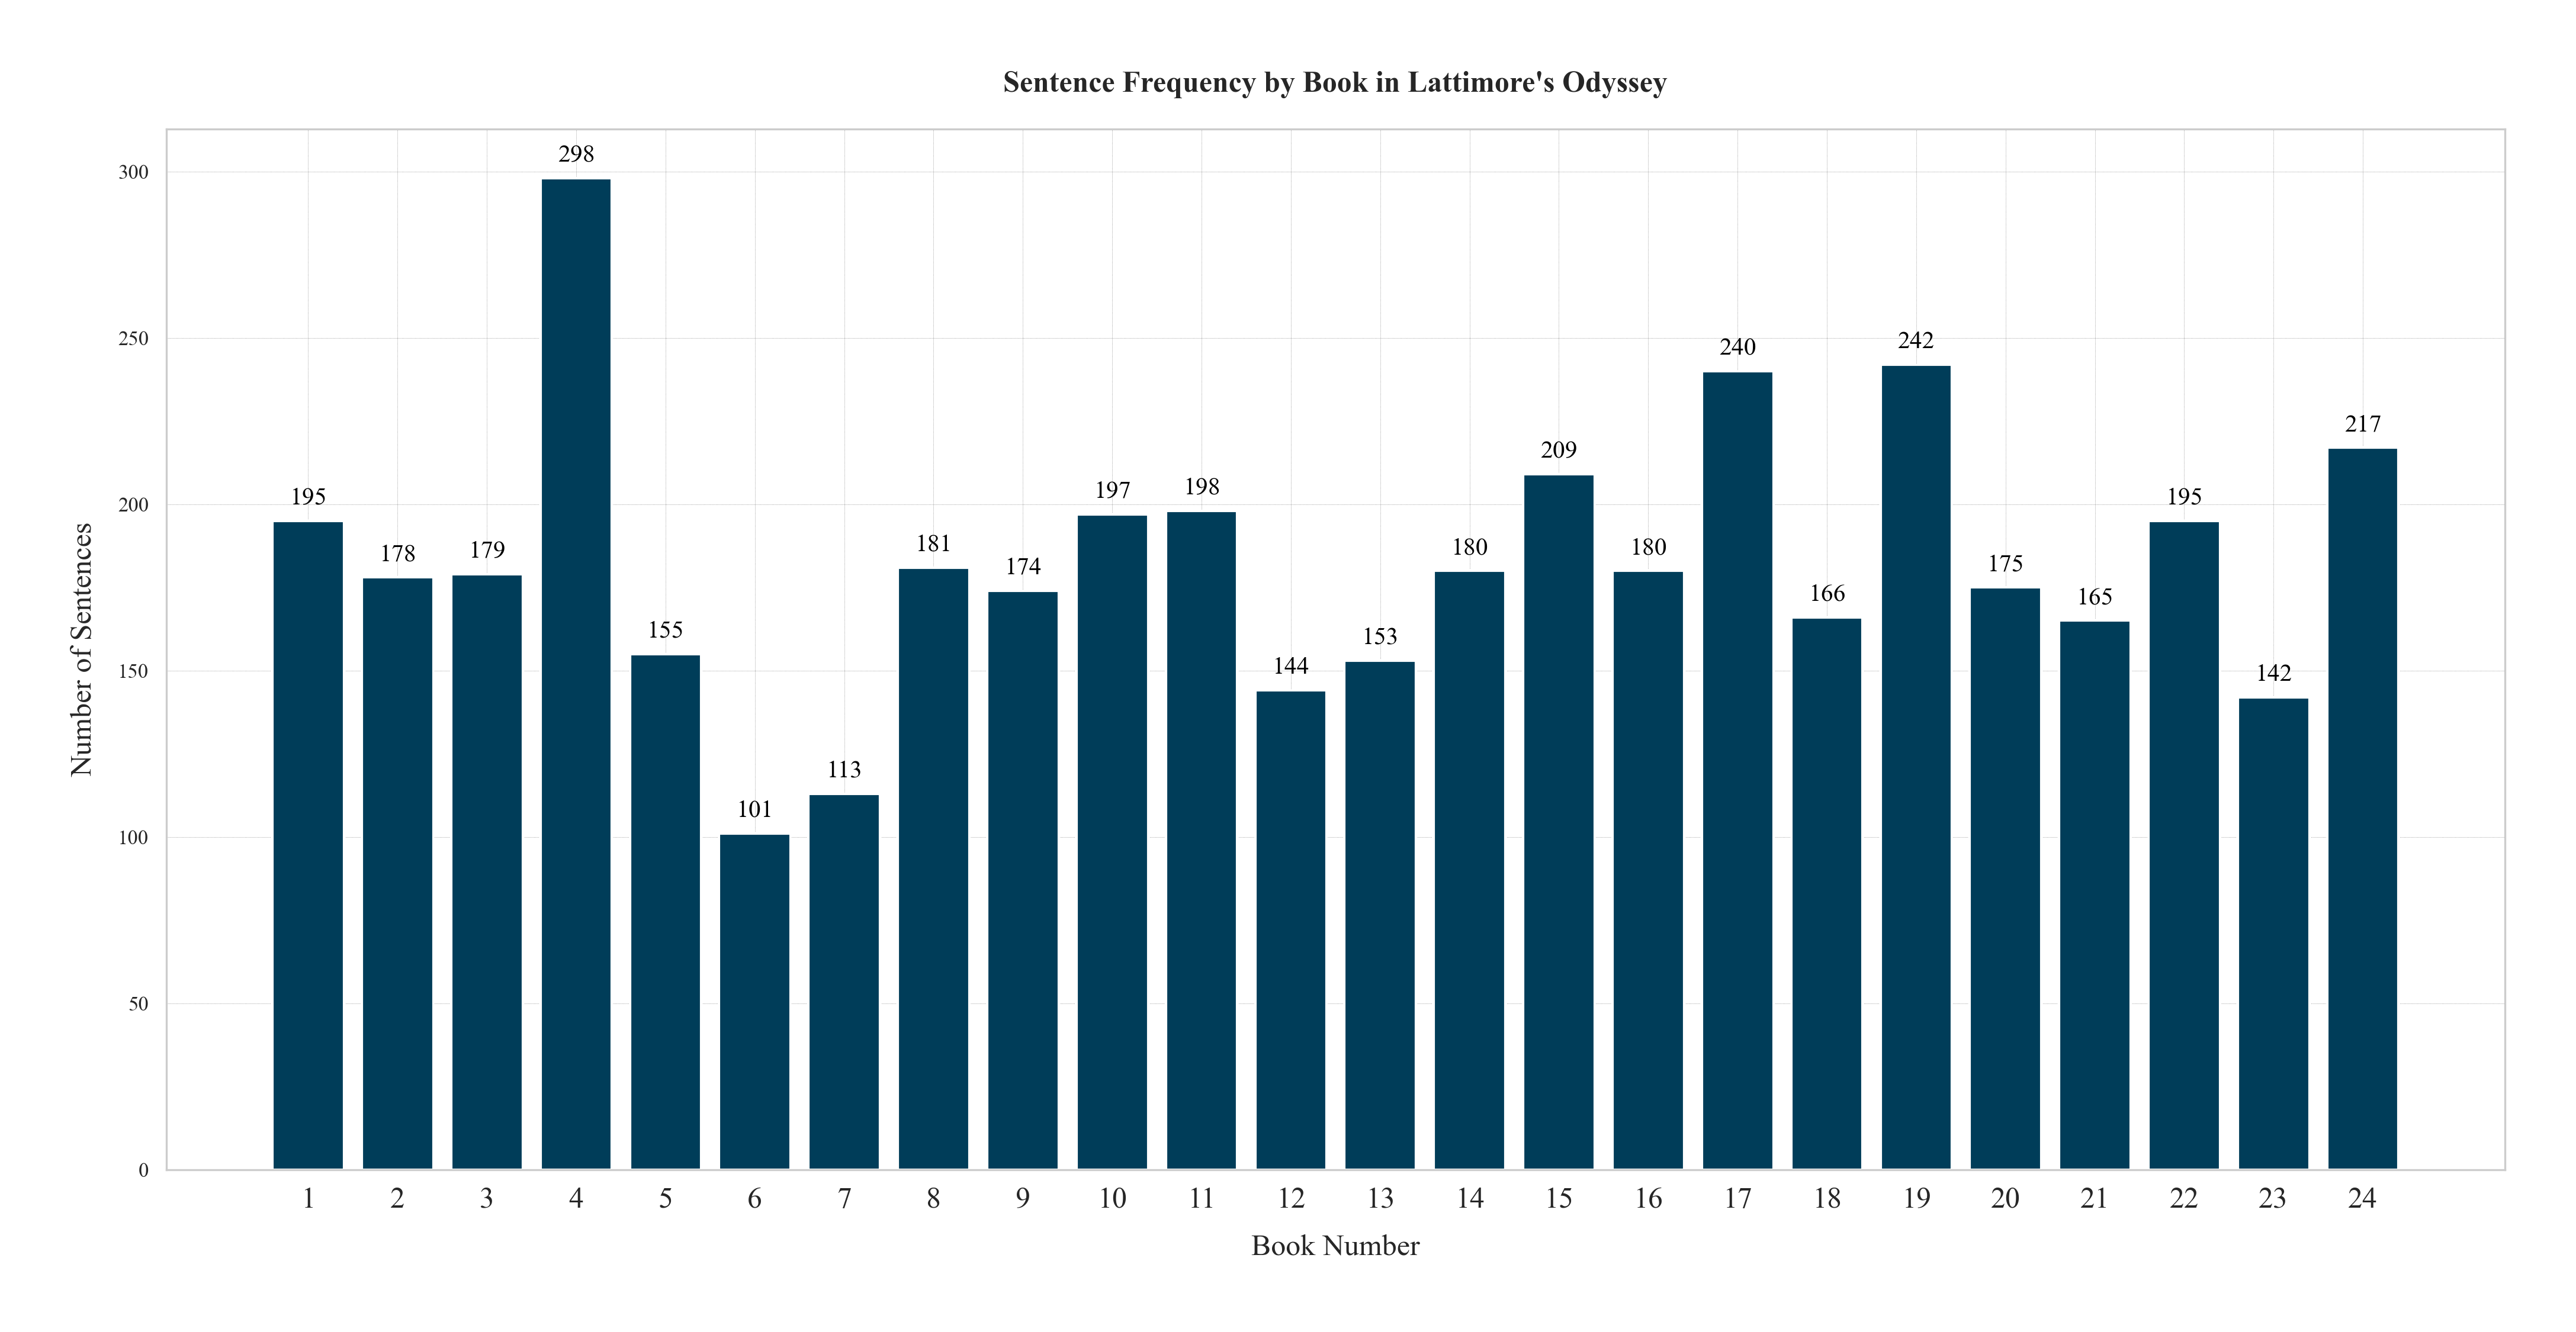

In [31]:
# Group by book_num and count the number of sentences in each book
sentences_per_book = df.groupby('book_num')['num_sentences'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))

# Use predefined color cycle from viz.COLORS
ax.bar(sentences_per_book.index, sentences_per_book.values)  # Use 'orange'

ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Sentences')
ax.set_title(f"Sentence Frequency by Book in {translator}'s Odyssey")

# Ensure all book numbers are shown on the x-axis
ax.set_xticks(sentences_per_book.index)

# Grid styling from viz
ax.grid(axis='y', alpha=0.5)
# Add values on top of bars
for i, v in enumerate(sentences_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

# Apply tight layout
plt.tight_layout()

# Save the figure using the predefined function
plt.savefig(f"{output_path_plots}/{translator}-sentence_freq.png")

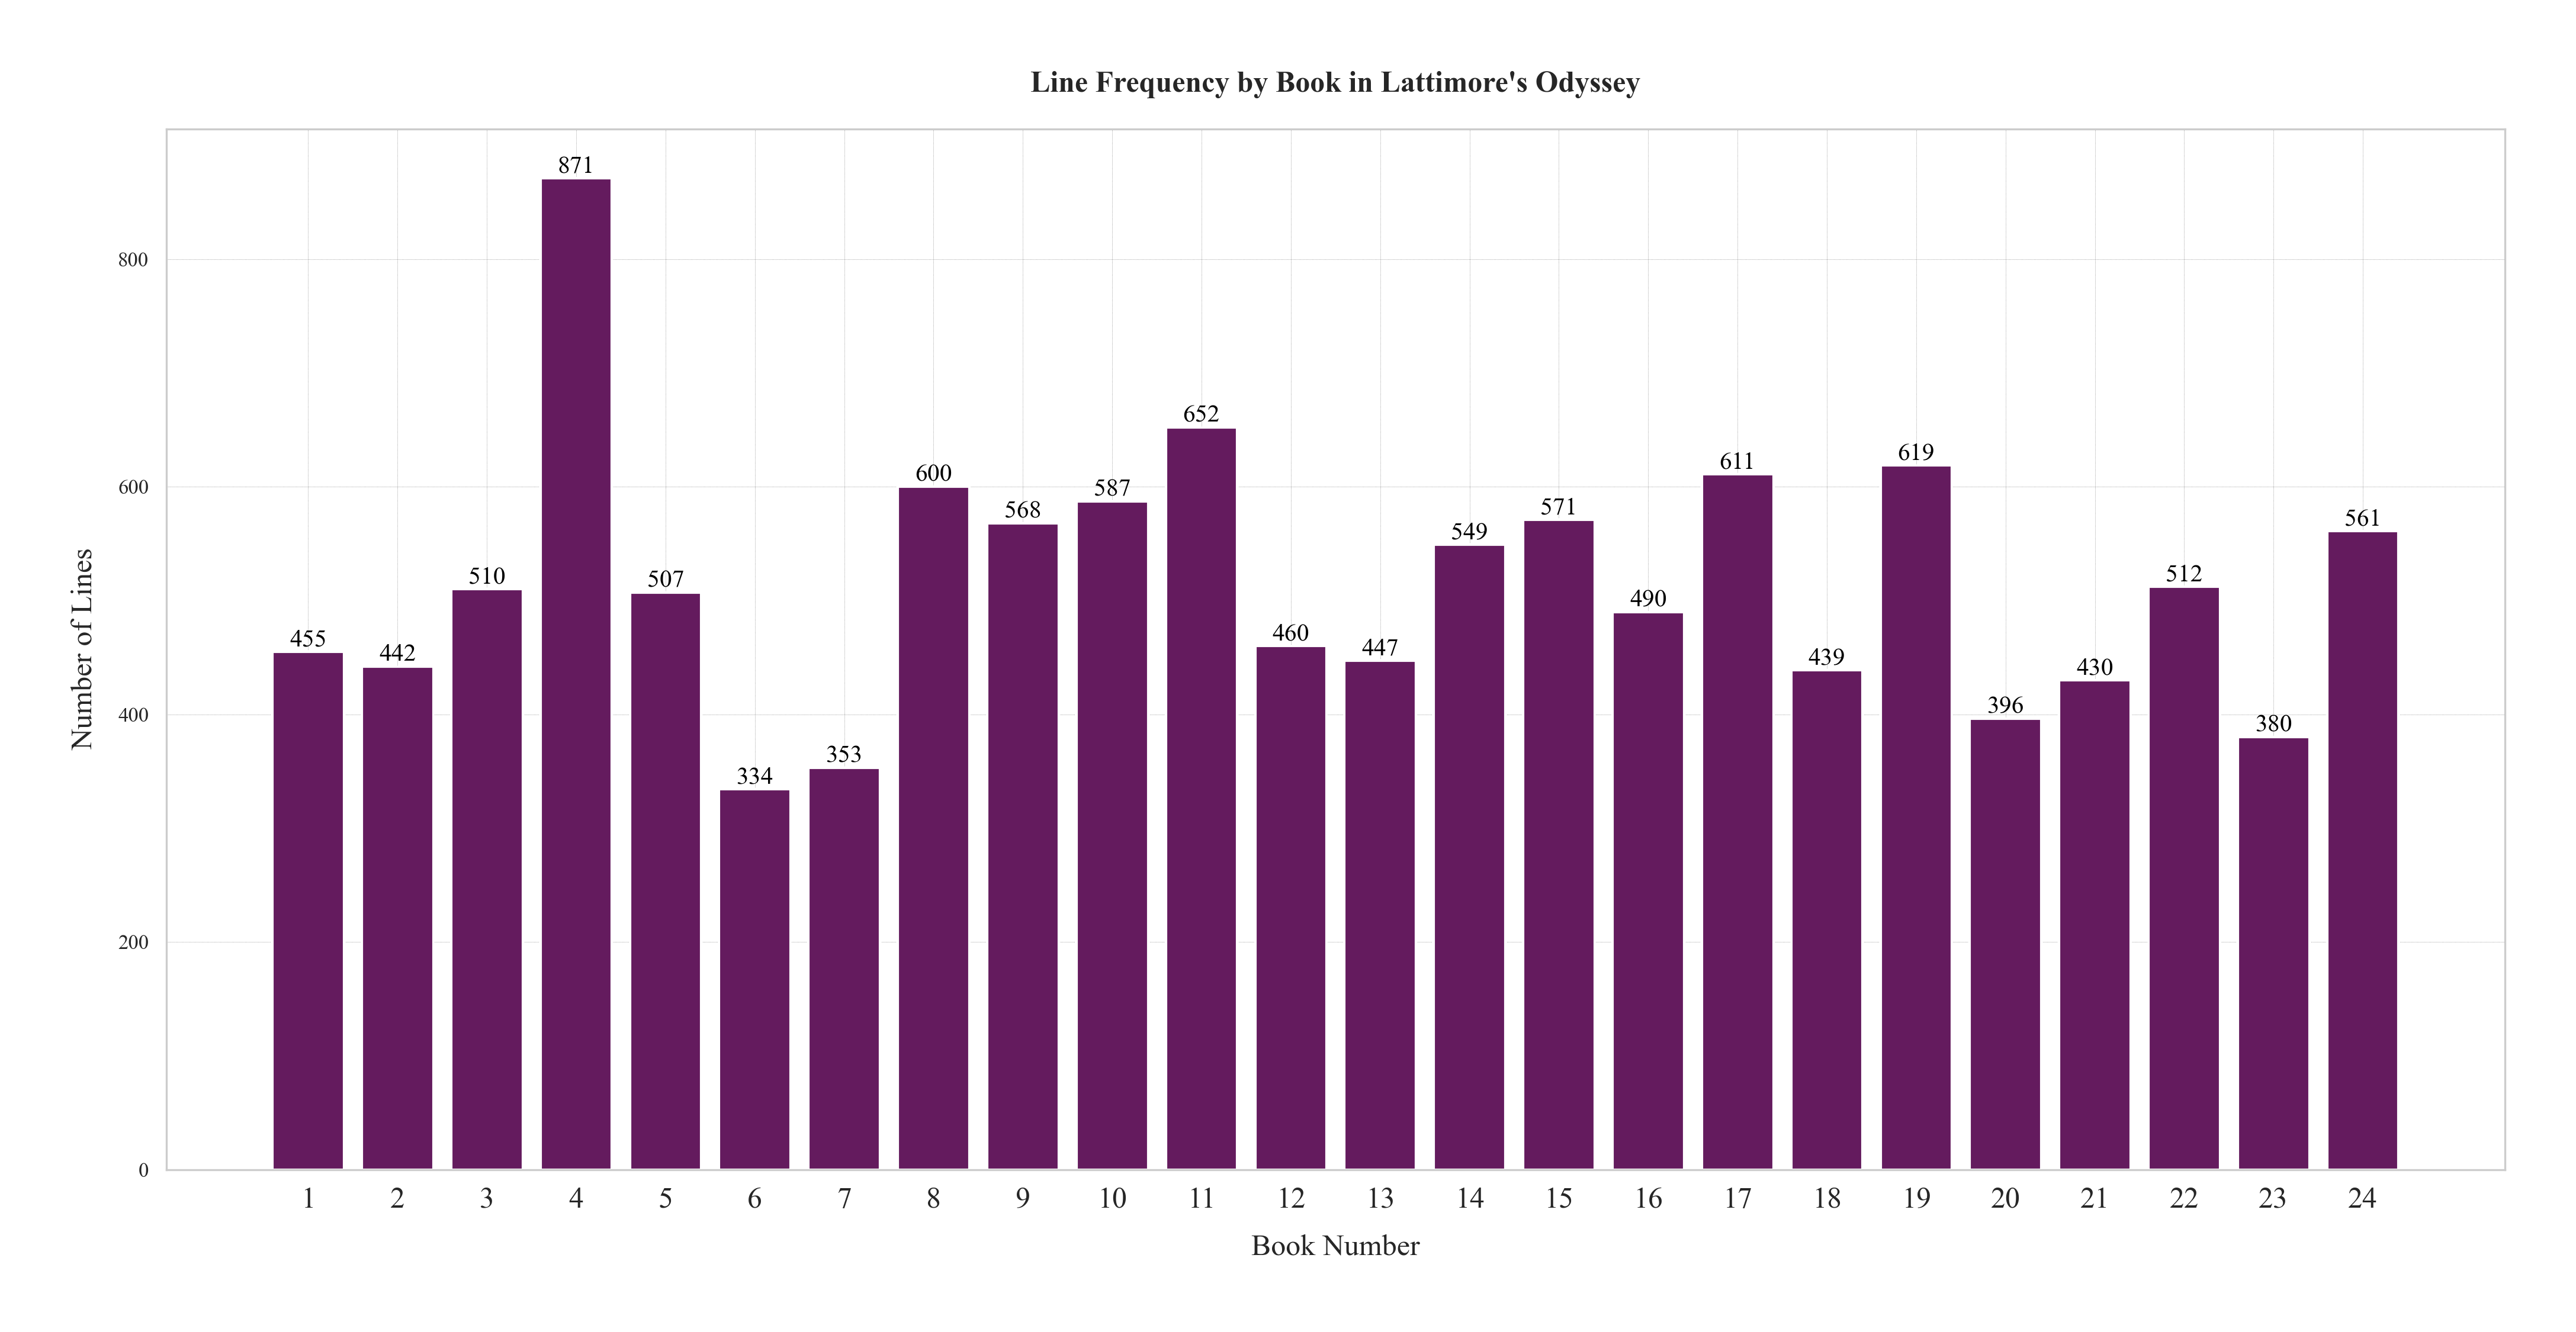

In [32]:
# Group by book_num and count the number of lines in each book
lines_per_book = df.groupby('book_num')['num_lines'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))

# Use predefined color cycle from viz.COLORS
ax.bar(lines_per_book.index, lines_per_book.values, color='#641B5E')  # Use 'orange'

ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Lines')
ax.set_title(f"Line Frequency by Book in {translator}'s Odyssey")

# Ensure all book numbers are shown on the x-axis
ax.set_xticks(lines_per_book.index)

# Grid styling from viz
ax.grid(axis='y', alpha=0.5)
# Add values on top of bars
for i, v in enumerate(lines_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

# Apply tight layout
plt.tight_layout()

# Save the figure using the predefined function
plt.savefig(f"{output_path_plots}/{translator}-lines_freq.png")

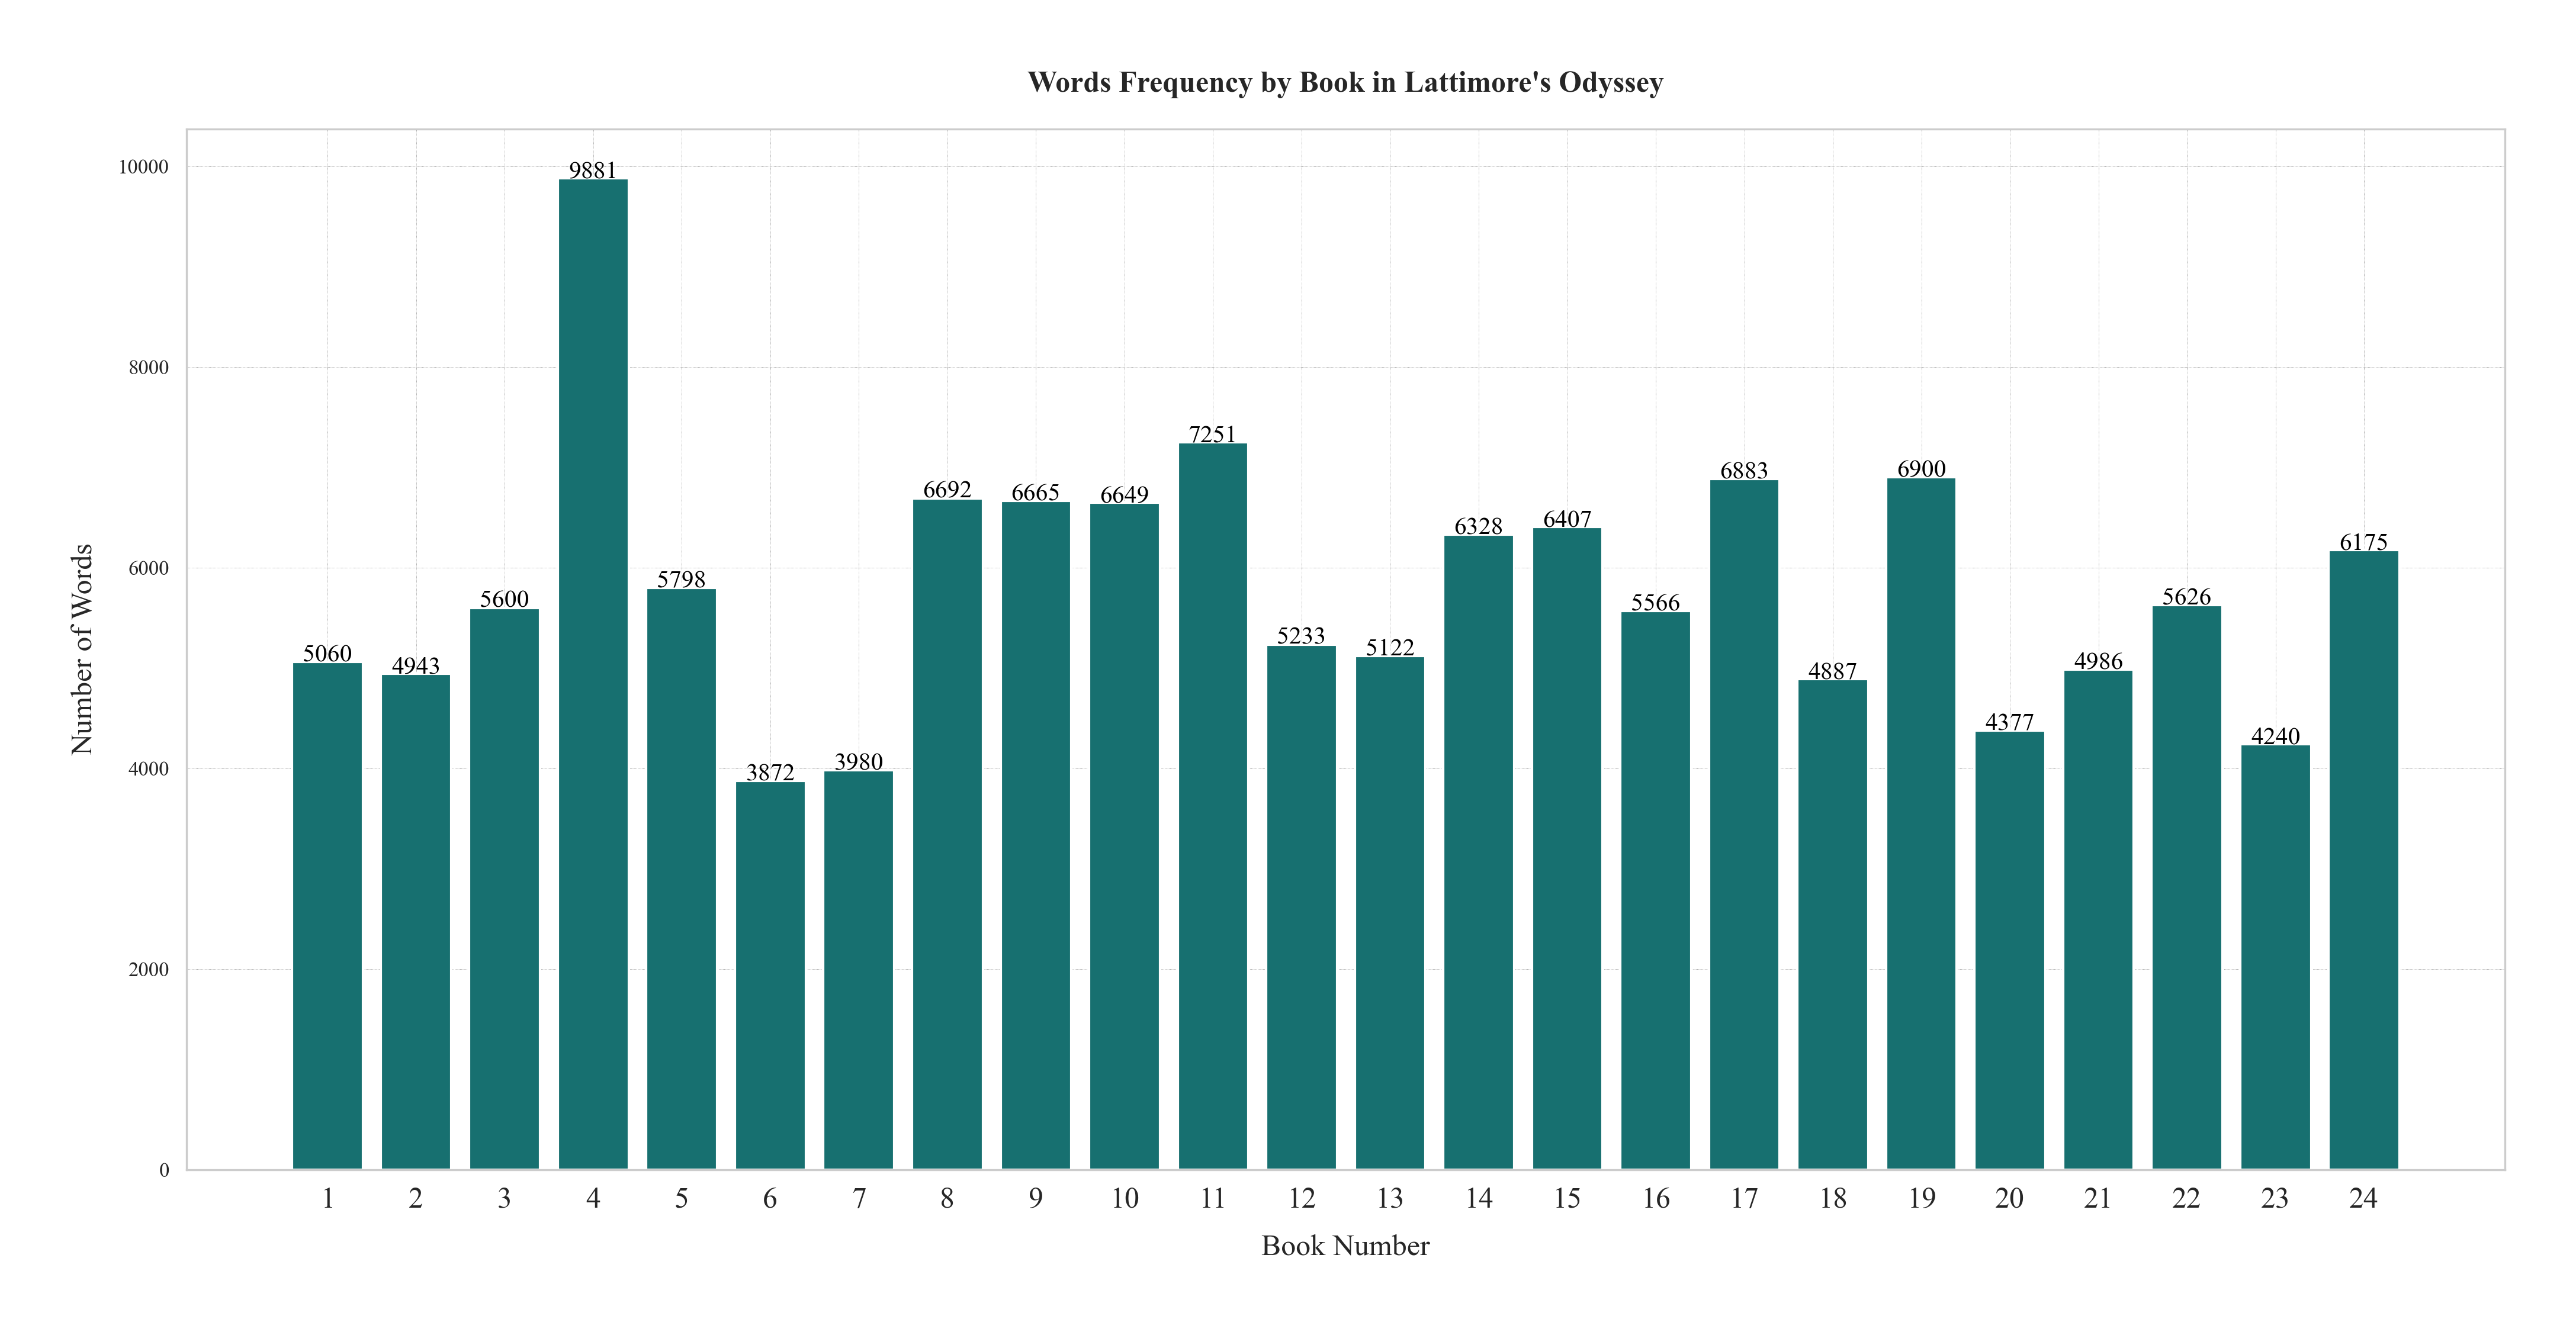

In [33]:
# Group by book_num and count the number of words in each book
words_per_book = df.groupby('book_num')['num_words'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))

# Use predefined color cycle from viz.COLORS
ax.bar(words_per_book.index, words_per_book.values, color='#177070')  # Use 'orange'

ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Words')
ax.set_title(f"Words Frequency by Book in {translator}'s Odyssey")

# Ensure all book numbers are shown on the x-axis
ax.set_xticks(words_per_book.index)

# Grid styling from viz
ax.grid(axis='y', alpha=0.5)
# Add values on top of bars
for i, v in enumerate(words_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

# Apply tight layout
plt.tight_layout()

# Save the figure using the predefined function
plt.savefig(f"{output_path_plots}/{translator}-words_freq_bB.png")

In [34]:
df['text'][0][:3]

['Tell me, Muse, of the man of many ways, who was driven\n',
 "far journeys, after he had sacked Troy's sacred citadel.\n",
 'Many were they whose cities he saw, whose minds he learned of,\n']

In [35]:
def remove_newlines(text_list):
    """Remove extra newlines from a list of strings.

    Args:
        text_list (list): A list of text lines.

    Returns:
        list: The list with extra newlines removed within each line.
    """
    return [re.sub(r'\n+', '', line) for line in text_list]  # Apply to each element in the list

df['text'] = df['text'].apply(remove_newlines)

In [36]:
df['text'][0][:3]

['Tell me, Muse, of the man of many ways, who was driven',
 "far journeys, after he had sacked Troy's sacred citadel.",
 'Many were they whose cities he saw, whose minds he learned of,']

In [37]:
#Boolean check for missing values
if df.isna().sum().sum() == 0:
    print("No missing values")
else:
    for col in df.columns:
        if df[col].isna().sum() > 0:
            print(f"Missing values in {col}")
print("\ndf columns:", df.columns, "\n\nShape:", df.shape)

No missing values

df columns: Index(['author', 'year', 'title', 'book_num', 'text', 'num_lines',
       'num_sentences', 'num_words'],
      dtype='object') 

Shape: (24, 8)


In [38]:
# Create directory OUTSIDE the project folder
output_filepath = f"/Users/debr/odysseys_en/Odyssey_dfs/Odyssey_{translator}_eda.csv"
os.makedirs(os.path.dirname(output_filepath), exist_ok=True)

# save df to csv
df.to_csv(output_filepath, index=False)

print(f"Normalization complete. File saved to: {output_filepath}")

Normalization complete. File saved to: /Users/debr/odysseys_en/Odyssey_dfs/Odyssey_Lattimore_eda.csv
